In [9]:
!pip -q install seaborn

In [10]:
# Part 1: Load and Prepare the Dataset
# In this section, I load the Titanic dataset, select the features I want to use, handle missing values, and create simple additional features.

In [11]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
sns.load_dataset("titanic")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [13]:
import os

os.makedirs("artifacts/data", exist_ok=True)
df.to_csv("artifacts/data/titanic.csv", index=False)

print("Saved Titanic dataset to artifacts/data/titanic.csv")
print(df.shape)

Saved Titanic dataset to artifacts/data/titanic.csv
(891, 15)


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [15]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [16]:
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()

df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1


In [17]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
family_size,0
is_alone,0


In [18]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
print(df.dtypes)

print("\nNumeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(exclude=np.number).columns.tolist())

Rows: 891
Columns: 10

Data types:
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
family_size      int64
is_alone         int64
dtype: object

Numeric columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']

Categorical columns:
['sex', 'embarked']


In [19]:
## Dataset Introduction

# This dataset contains information about passengers on the Titanic, including their passenger class, sex, age, fare, family information, and port of embarkation. I used the Titanic dataset available through the Seaborn library.

# The prediction target is **survived**, where 1 means the passenger survived and 0 means the passenger did not survive. This is an interesting classification problem because it helps show how passenger characteristics may have influenced survival outcomes.

# The dataset has **891 rows** and **10 columns** after feature selection and simple feature engineering. It includes both **numerical features** such as age and fare, and **categorical features** such as sex and embarked.

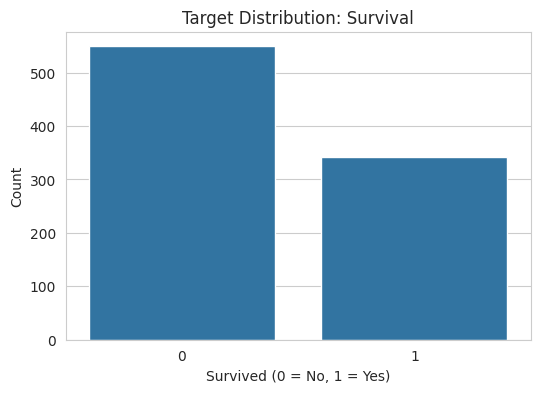

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")
plt.title("Target Distribution: Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [21]:
### Interpretation: Target Distribution

# This chart shows that more passengers did not survive than survived. The classes are not perfectly balanced, so I will pay attention to metrics like precision, recall, and F1 score later instead of only looking at accuracy.

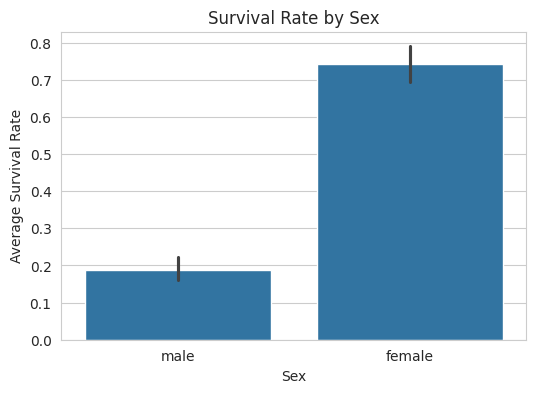

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.show()

In [23]:
### Interpretation: Survival by Sex

# This chart shows a strong difference in survival rate between male and female passengers. Female passengers had a much higher survival rate, which suggests that sex is likely to be one of the most important features in the prediction model.

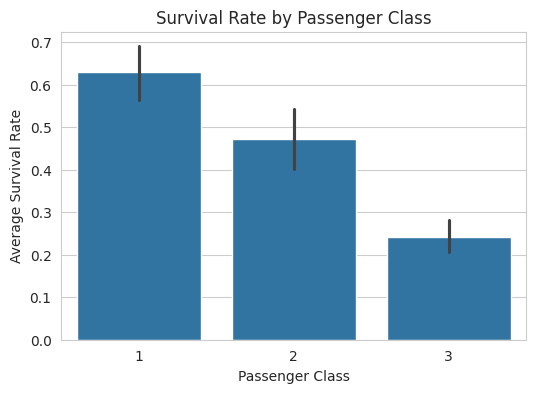

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival Rate")
plt.show()

In [25]:
### Interpretation: Survival by Passenger Class

# This chart shows that first-class passengers had the highest survival rate, while third-class passengers had the lowest. This suggests that passenger class is strongly related to survival and may capture differences in access, location, or resources during the disaster.

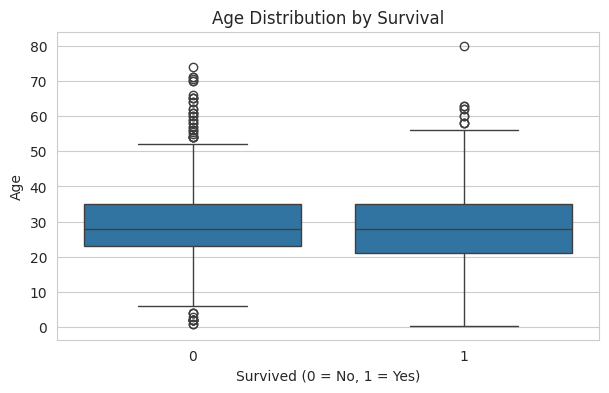

In [26]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

In [27]:
### Interpretation: Age by Survival

# This plot compares the age distribution of passengers who survived and those who did not. The two groups overlap, but the chart helps show whether younger or older passengers had slightly different survival patterns, which may still be useful for modeling.

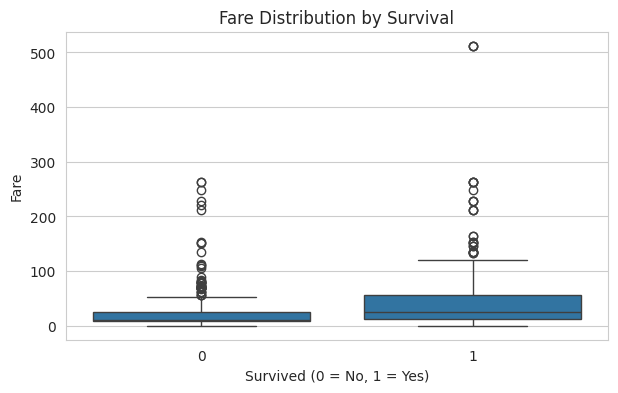

In [28]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

In [29]:
### Interpretation: Fare by Survival

# This chart shows that passengers who survived often had higher ticket fares than those who did not survive. Since fare is often related to wealth and passenger class, this suggests that fare may also be an important predictor of survival.

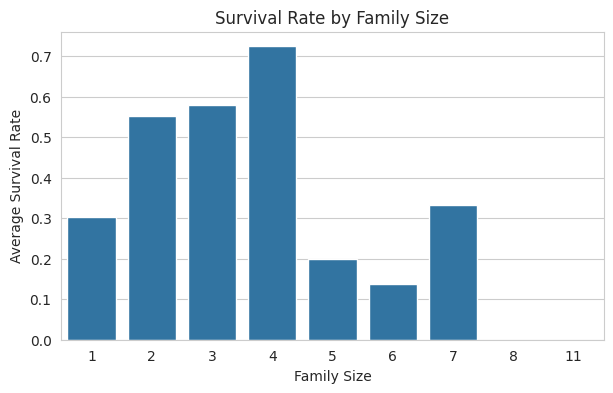

In [30]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="family_size", y="survived", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")
plt.show()

In [31]:
### Interpretation: Survival by Family Size

# This chart shows how survival changes across different family sizes. It may suggest that traveling completely alone or in very large groups affected survival chances differently, which is why family-related features may add useful information to the model.

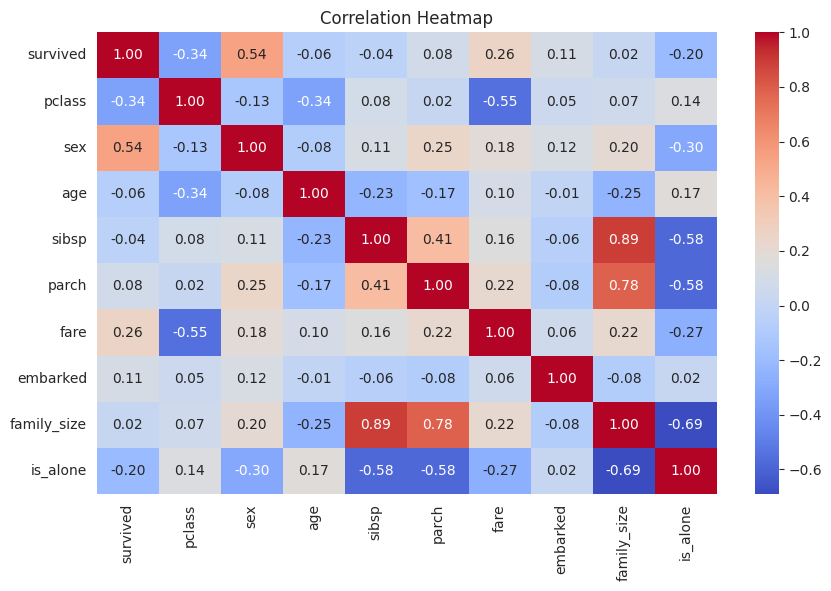

In [32]:
corr_df = df.copy()

corr_df["sex"] = corr_df["sex"].map({"male": 0, "female": 1})
corr_df["embarked"] = corr_df["embarked"].map({"S": 0, "C": 1, "Q": 2})

plt.figure(figsize=(10,6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [33]:
### Interpretation: Correlation Heatmap

# The heatmap shows that survival has a strong positive relationship with being female and a negative relationship with lower passenger class values after encoding. Fare and passenger class also show meaningful relationships, which supports the earlier visual findings that class, sex, and fare are likely to be important features in the models.

In [34]:
import os

os.makedirs("artifacts/data", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

df.to_csv("artifacts/data/titanic_clean.csv", index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.


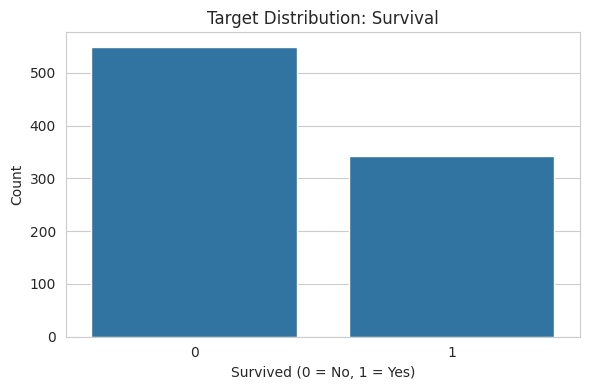

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")
plt.title("Target Distribution: Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("artifacts/figures/target_distribution.png", dpi=300)
plt.show()

In [36]:
# Part 2: Dataset Introduction
# This section describes the dataset, the target variable, and the basic structure of the data.

In [37]:
!pip -q install scikit-learn xgboost tensorflow joblib

X_train shape: (623, 9)
X_test shape: (268, 9)
Processed training shape: (623, 14)
Processed test shape: (268, 14)

Logistic Regression Metrics:
{'accuracy': 0.8059701492537313, 'precision': 0.7628865979381443, 'recall': 0.7184466019417476, 'f1': 0.74, 'roc_auc': 0.8551044424830833, 'model': 'Logistic Regression'}


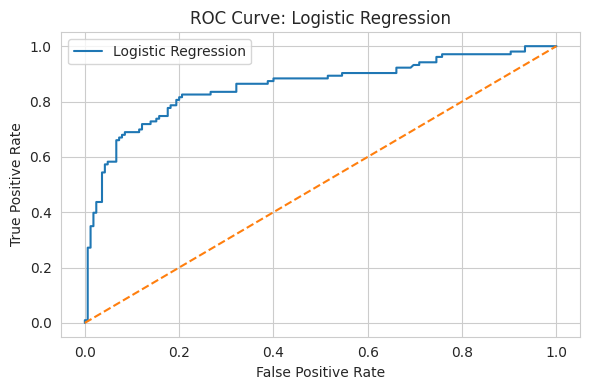


Best Decision Tree Params:
{'max_depth': 10, 'min_samples_leaf': 10}
Decision Tree Metrics:
{'accuracy': 0.7835820895522388, 'precision': 0.7777777777777778, 'recall': 0.6116504854368932, 'f1': 0.6847826086956522, 'roc_auc': 0.8215357458075905, 'model': 'Decision Tree'}


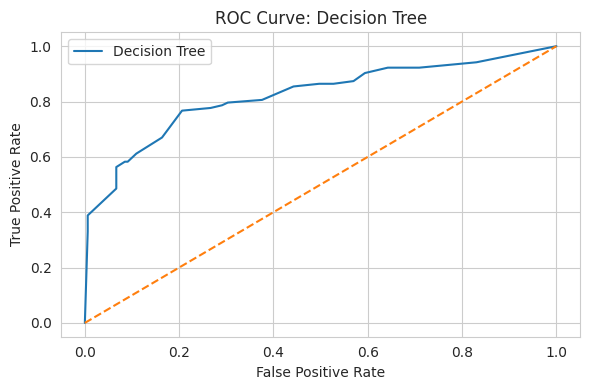


Best Random Forest Params:
{'max_depth': 8, 'n_estimators': 100}
Random Forest Metrics:
{'accuracy': 0.7947761194029851, 'precision': 0.7608695652173914, 'recall': 0.6796116504854369, 'f1': 0.717948717948718, 'roc_auc': 0.8583995292733158, 'model': 'Random Forest'}


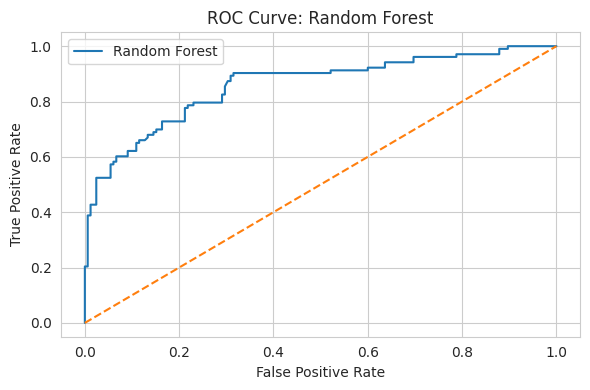


Best XGBoost Params:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
XGBoost Metrics:
{'accuracy': 0.7947761194029851, 'precision': 0.7727272727272727, 'recall': 0.6601941747572816, 'f1': 0.7120418848167539, 'roc_auc': 0.8477493380406003, 'model': 'XGBoost'}


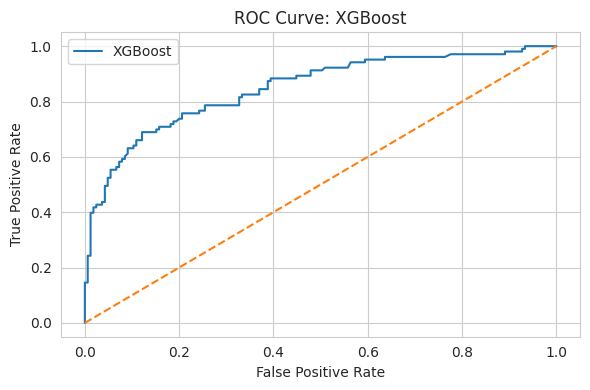

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6446 - loss: 0.6118 - val_accuracy: 0.7680 - val_loss: 0.5432
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7631 - loss: 0.5001 - val_accuracy: 0.7680 - val_loss: 0.4976
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8133 - loss: 0.4469 - val_accuracy: 0.8000 - val_loss: 0.4603
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8253 - loss: 0.4234 - val_accuracy: 0.7920 - val_loss: 0.4598
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8153 - loss: 0.4064 - val_accuracy: 0.7920 - val_loss: 0.4650
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8273 - loss: 0.3922 - val_accuracy: 0.8080 - val_loss: 0.4620
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8434 - loss: 0.3827 - val_accuracy: 0.8000 - val_loss: 0.4613
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8434 - loss: 0.3769 - val_accuracy: 0.8000 - val_loss: 0.4686
E

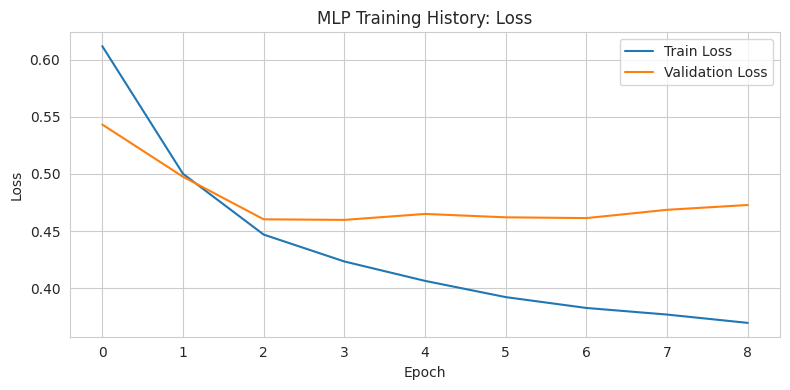

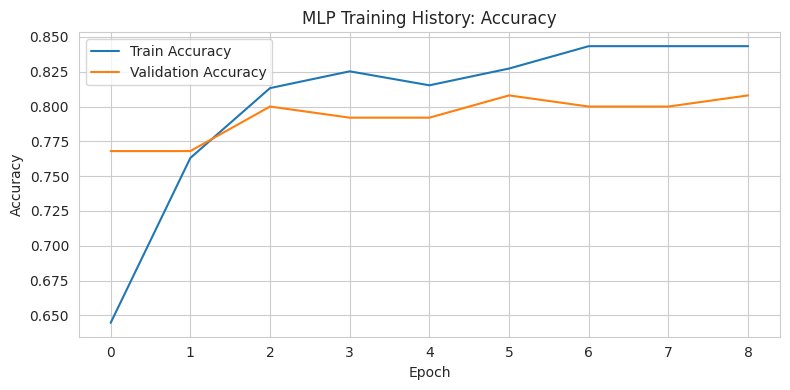

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

MLP Metrics:
{'accuracy': 0.8059701492537313, 'precision': 0.7475728155339806, 'recall': 0.7475728155339806, 'f1': 0.7475728155339806, 'roc_auc': 0.8553103854074727, 'model': 'MLP Neural Network'}


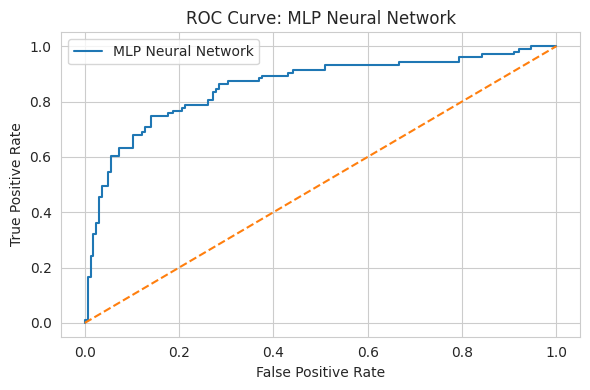

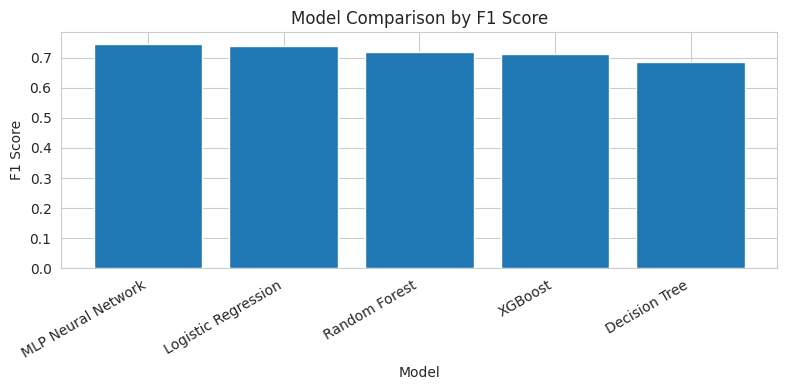


=== FINAL MODEL COMPARISON ===
                 model  accuracy  precision    recall        f1   roc_auc
4   MLP Neural Network  0.805970   0.747573  0.747573  0.747573  0.855310
0  Logistic Regression  0.805970   0.762887  0.718447  0.740000  0.855104
2        Random Forest  0.794776   0.760870  0.679612  0.717949  0.858400
3              XGBoost  0.794776   0.772727  0.660194  0.712042  0.847749
1        Decision Tree  0.783582   0.777778  0.611650  0.684783  0.821536

Saved files in artifacts/models:
['mlp_model.keras', 'model_results.csv', 'preprocessor.joblib', 'decision_tree.joblib', 'logistic_regression.joblib', 'best_params.json', 'random_forest.joblib', 'xgboost.joblib', 'feature_names.json']

Saved files in artifacts/figures:
['mlp_accuracy_curve.png', 'roc_random_forest.png', 'roc_logistic_regression.png', 'roc_decision_tree.png', 'roc_mlp.png', 'target_distribution.png', 'model_comparison_f1.png', 'roc_xgboost.png', 'mlp_loss_curve.png']


In [38]:
# =========================
# PART 2: PREDICTIVE ANALYTICS (ONE CELL)
# Run this AFTER Part 1, in the same notebook
# =========================

!pip -q install scikit-learn xgboost tensorflow joblib

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# Create folders
# -------------------------
os.makedirs("artifacts/models", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

# -------------------------
# Train/test split
# -------------------------
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# -------------------------
# Preprocessing
# -------------------------
categorical_features = ["sex", "embarked", "pclass"]
numeric_features = ["age", "sibsp", "parch", "fare", "family_size", "is_alone"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out().tolist()

with open("artifacts/models/feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

joblib.dump(preprocessor, "artifacts/models/preprocessor.joblib")

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# -------------------------
# Helper functions
# -------------------------
results = []
best_params = {}

def get_classification_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob))
    }

def save_roc_curve(y_true, y_prob, model_name, filename):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=model_name)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# -------------------------
# 1. Logistic Regression (Baseline)
# -------------------------
log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_processed, y_train)

y_pred_log = log_model.predict(X_test_processed)
y_prob_log = log_model.predict_proba(X_test_processed)[:, 1]

log_metrics = get_classification_metrics(y_test, y_pred_log, y_prob_log)
log_metrics["model"] = "Logistic Regression"
results.append(log_metrics)

print("\nLogistic Regression Metrics:")
print(log_metrics)

save_roc_curve(
    y_test,
    y_prob_log,
    "Logistic Regression",
    "artifacts/figures/roc_logistic_regression.png"
)

joblib.dump(log_model, "artifacts/models/logistic_regression.joblib")

# -------------------------
# 2. Decision Tree + GridSearchCV
# -------------------------
dt_model = DecisionTreeClassifier(random_state=42)

dt_param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [5, 10, 20]
}

dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train_processed, y_train)
best_dt = dt_grid.best_estimator_
best_params["Decision Tree"] = dt_grid.best_params_

y_pred_dt = best_dt.predict(X_test_processed)
y_prob_dt = best_dt.predict_proba(X_test_processed)[:, 1]

dt_metrics = get_classification_metrics(y_test, y_pred_dt, y_prob_dt)
dt_metrics["model"] = "Decision Tree"
results.append(dt_metrics)

print("\nBest Decision Tree Params:")
print(dt_grid.best_params_)
print("Decision Tree Metrics:")
print(dt_metrics)

save_roc_curve(
    y_test,
    y_prob_dt,
    "Decision Tree",
    "artifacts/figures/roc_decision_tree.png"
)

joblib.dump(best_dt, "artifacts/models/decision_tree.joblib")

# -------------------------
# 3. Random Forest + GridSearchCV
# -------------------------
rf_model = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 8]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)
best_rf = rf_grid.best_estimator_
best_params["Random Forest"] = rf_grid.best_params_

y_pred_rf = best_rf.predict(X_test_processed)
y_prob_rf = best_rf.predict_proba(X_test_processed)[:, 1]

rf_metrics = get_classification_metrics(y_test, y_pred_rf, y_prob_rf)
rf_metrics["model"] = "Random Forest"
results.append(rf_metrics)

print("\nBest Random Forest Params:")
print(rf_grid.best_params_)
print("Random Forest Metrics:")
print(rf_metrics)

save_roc_curve(
    y_test,
    y_prob_rf,
    "Random Forest",
    "artifacts/figures/roc_random_forest.png"
)

joblib.dump(best_rf, "artifacts/models/random_forest.joblib")

# -------------------------
# 4. XGBoost + GridSearchCV
# -------------------------
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_processed, y_train)
best_xgb = xgb_grid.best_estimator_
best_params["XGBoost"] = xgb_grid.best_params_

y_pred_xgb = best_xgb.predict(X_test_processed)
y_prob_xgb = best_xgb.predict_proba(X_test_processed)[:, 1]

xgb_metrics = get_classification_metrics(y_test, y_pred_xgb, y_prob_xgb)
xgb_metrics["model"] = "XGBoost"
results.append(xgb_metrics)

print("\nBest XGBoost Params:")
print(xgb_grid.best_params_)
print("XGBoost Metrics:")
print(xgb_metrics)

save_roc_curve(
    y_test,
    y_prob_xgb,
    "XGBoost",
    "artifacts/figures/roc_xgboost.png"
)

joblib.dump(best_xgb, "artifacts/models/xgboost.joblib")

# -------------------------
# 5. Neural Network (MLP)
# -------------------------
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

mlp_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_dense.shape[1],)),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_dense,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# MLP loss plot
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MLP Training History: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/mlp_loss_curve.png", dpi=300)
plt.show()
plt.close()

# MLP accuracy plot
plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MLP Training History: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/mlp_accuracy_curve.png", dpi=300)
plt.show()
plt.close()

y_prob_mlp = mlp_model.predict(X_test_dense).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

mlp_metrics = get_classification_metrics(y_test, y_pred_mlp, y_prob_mlp)
mlp_metrics["model"] = "MLP Neural Network"
results.append(mlp_metrics)

print("\nMLP Metrics:")
print(mlp_metrics)

save_roc_curve(
    y_test,
    y_prob_mlp,
    "MLP Neural Network",
    "artifacts/figures/roc_mlp.png"
)

mlp_model.save("artifacts/models/mlp_model.keras")

# -------------------------
# Results table + comparison chart
# -------------------------
results_df = pd.DataFrame(results)
results_df = results_df[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
results_df = results_df.sort_values(by="f1", ascending=False)

results_df.to_csv("artifacts/models/model_results.csv", index=False)

with open("artifacts/models/best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

plt.figure(figsize=(8,4))
plt.bar(results_df["model"], results_df["f1"])
plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("artifacts/figures/model_comparison_f1.png", dpi=300)
plt.show()
plt.close()

print("\n=== FINAL MODEL COMPARISON ===")
print(results_df)

print("\nSaved files in artifacts/models:")
print(os.listdir("artifacts/models"))

print("\nSaved files in artifacts/figures:")
print(os.listdir("artifacts/figures"))

In [39]:
# Part 3: Exploratory Data Analysis (EDA)
# In this section, I explore patterns in the Titanic dataset using visualizations and short interpretations.

In [40]:
import os
import pandas as pd
import numpy as np
import seaborn as sns

os.makedirs("artifacts/data", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)
os.makedirs("artifacts/models", exist_ok=True)

# Try to load the dataset from saved files first
if os.path.exists("artifacts/data/titanic_clean.csv"):
    df = pd.read_csv("artifacts/data/titanic_clean.csv")
    print("Loaded existing cleaned dataset: artifacts/data/titanic_clean.csv")

elif os.path.exists("artifacts/data/titanic.csv"):
    df = pd.read_csv("artifacts/data/titanic.csv")
    print("Loaded existing raw dataset: artifacts/data/titanic.csv")

else:
    df = sns.load_dataset("titanic")
    print("Loaded dataset from seaborn: sns.load_dataset('titanic')")
    df.to_csv("artifacts/data/titanic.csv", index=False)
    print("Saved raw dataset to artifacts/data/titanic.csv")

# Keep only the simple features we are using
if "survived" in df.columns:
    df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()

# Feature engineering
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)

# Fill missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Save cleaned version
df.to_csv("artifacts/data/titanic_clean.csv", index=False)

print("\nDataset is ready.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

Loaded existing cleaned dataset: artifacts/data/titanic_clean.csv

Dataset is ready.
Shape: (891, 10)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1


In [41]:
import os
print(os.listdir("artifacts/models"))

['mlp_model.keras', 'model_results.csv', 'preprocessor.joblib', 'decision_tree.joblib', 'logistic_regression.joblib', 'best_params.json', 'random_forest.joblib', 'xgboost.joblib', 'feature_names.json']


Loaded model results and preprocessor.
Best tree-based model for SHAP: Random Forest
Loaded cleaned dataset.
Shape: (891, 10)
Processed train shape: (623, 14)
Processed test shape: (268, 14)


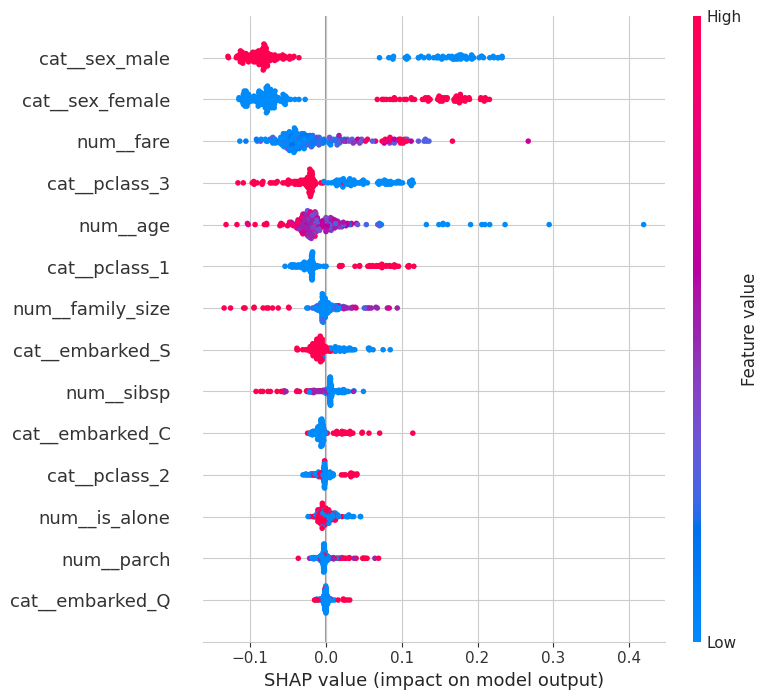

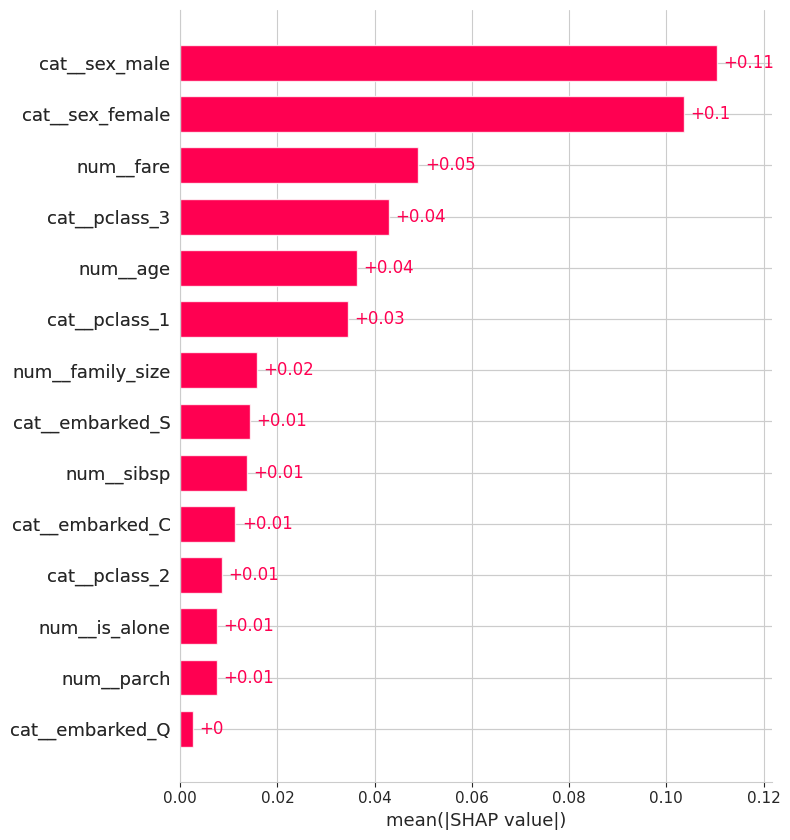

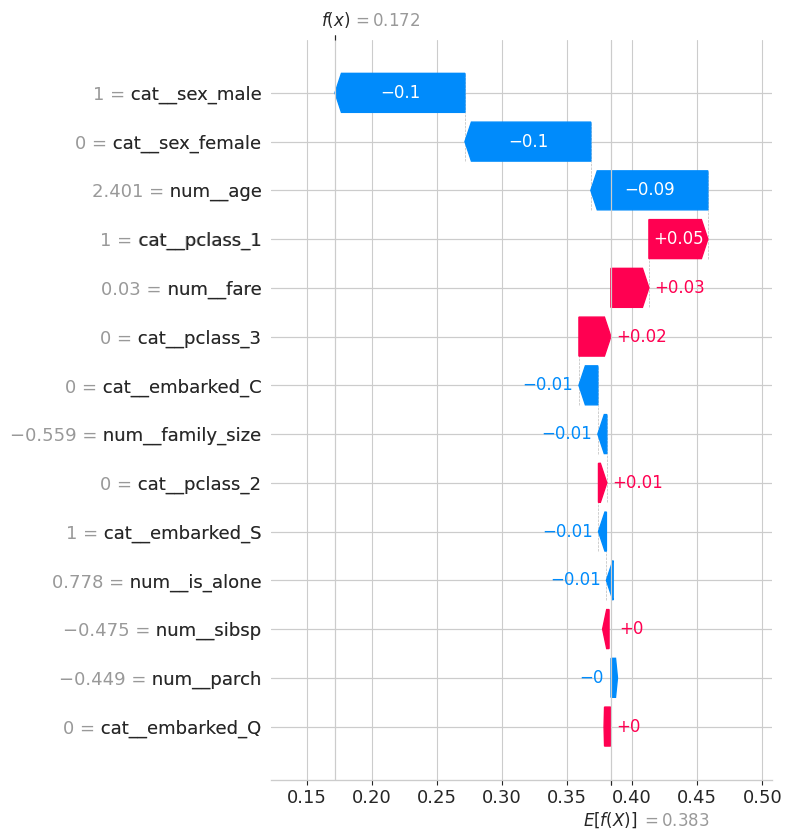


SHAP is done.

Saved SHAP files in artifacts/figures:
['shap_beeswarm.png', 'shap_waterfall_example.png', 'shap_bar.png']

Saved SHAP helper files in artifacts/models:
['shap_background.npy', 'shap_info.json']


In [53]:
# =========================
# PART 3: SHAP EXPLAINABILITY
# Run this AFTER Part 2 is done
# =========================

!pip -q install shap

import os
import json
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# -------------------------
# 1. Make sure folders exist
# -------------------------
os.makedirs("artifacts/figures", exist_ok=True)
os.makedirs("artifacts/models", exist_ok=True)

# -------------------------
# 2. Load the saved files from Part 2
# -------------------------
results_df = pd.read_csv("artifacts/models/model_results.csv")
preprocessor = joblib.load("artifacts/models/preprocessor.joblib")

print("Loaded model results and preprocessor.")

# -------------------------
# 3. Pick the best tree-based model
# Only tree-based models should be used for SHAP here
# -------------------------
tree_models = ["Decision Tree", "Random Forest", "XGBoost"]
tree_results = results_df[results_df["model"].isin(tree_models)].copy()

best_tree_name = tree_results.sort_values(by="f1", ascending=False).iloc[0]["model"]

if best_tree_name == "Decision Tree":
    best_tree_model = joblib.load("artifacts/models/decision_tree.joblib")
elif best_tree_name == "Random Forest":
    best_tree_model = joblib.load("artifacts/models/random_forest.joblib")
else:
    best_tree_model = joblib.load("artifacts/models/xgboost.joblib")

print("Best tree-based model for SHAP:", best_tree_name)

# -------------------------
# 4. Load the cleaned Titanic dataset
# This keeps everything consistent with your earlier steps
# -------------------------
df_shap = pd.read_csv("artifacts/data/titanic_clean.csv")

print("Loaded cleaned dataset.")
print("Shape:", df_shap.shape)

# -------------------------
# 5. Recreate X and y
# -------------------------
X = df_shap.drop(columns=["survived"])
y = df_shap["survived"]

# -------------------------
# 6. Recreate the same train/test split from Part 2
# Use the same random_state and stratify so it matches
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -------------------------
# 7. Transform the data using the saved preprocessor
# -------------------------
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert to dense arrays if needed
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

feature_names = preprocessor.get_feature_names_out().tolist()

print("Processed train shape:", X_train_dense.shape)
print("Processed test shape:", X_test_dense.shape)

# -------------------------
# 8. Create a small background sample for SHAP
# This makes SHAP faster
# -------------------------
background_size = min(200, X_train_dense.shape[0])
rng = np.random.RandomState(42)
background_idx = rng.choice(X_train_dense.shape[0], size=background_size, replace=False)
background_data = X_train_dense[background_idx]

# Save background data for Streamlit later
np.save("artifacts/models/shap_background.npy", background_data)

# -------------------------
# 9. Build the SHAP explainer
# -------------------------
explainer = shap.TreeExplainer(best_tree_model)

# Use the background sample for global plots
raw_shap_values = explainer(background_data)

# -------------------------
# 10. Fix SHAP output shape if model is multi-output
# For binary classification, we want the class-1 explanation
# -------------------------
if len(raw_shap_values.values.shape) == 3:
    shap_values = shap.Explanation(
        values=raw_shap_values.values[:, :, 1],
        base_values=raw_shap_values.base_values[:, 1] if len(np.array(raw_shap_values.base_values).shape) > 1 else raw_shap_values.base_values,
        data=raw_shap_values.data,
        feature_names=feature_names
    )
else:
    shap_values = shap.Explanation(
        values=raw_shap_values.values,
        base_values=raw_shap_values.base_values,
        data=raw_shap_values.data,
        feature_names=feature_names
    )

# -------------------------
# 11. SHAP beeswarm plot
# -------------------------
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig("artifacts/figures/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------
# 12. SHAP bar plot
# -------------------------
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig("artifacts/figures/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------
# 13. SHAP waterfall plot for one test example
# -------------------------
one_input = X_test_dense[0:1]
raw_one_shap = explainer(one_input)

if len(raw_one_shap.values.shape) == 3:
    one_shap = shap.Explanation(
        values=raw_one_shap.values[0, :, 1],
        base_values=raw_one_shap.base_values[0, 1] if len(np.array(raw_one_shap.base_values).shape) > 1 else raw_one_shap.base_values[0],
        data=raw_one_shap.data[0],
        feature_names=feature_names
    )
else:
    one_shap = shap.Explanation(
        values=raw_one_shap.values[0],
        base_values=raw_one_shap.base_values[0] if len(np.array(raw_one_shap.base_values).shape) > 0 else raw_one_shap.base_values,
        data=raw_one_shap.data[0],
        feature_names=feature_names
    )

plt.figure()
shap.plots.waterfall(one_shap, max_display=15, show=False)
plt.tight_layout()
plt.savefig("artifacts/figures/shap_waterfall_example.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------
# 14. Save a small info file for the Streamlit app
# -------------------------
shap_info = {
    "best_tree_model_for_shap": best_tree_name,
    "waterfall_example_index": 0
}

with open("artifacts/models/shap_info.json", "w") as f:
    json.dump(shap_info, f, indent=4)

# -------------------------
# 15. Print confirmation
# -------------------------
print("\nSHAP is done.")
print("\nSaved SHAP files in artifacts/figures:")
print([f for f in os.listdir("artifacts/figures") if "shap" in f])

print("\nSaved SHAP helper files in artifacts/models:")
print([f for f in os.listdir("artifacts/models") if "shap" in f])

In [42]:
# Part 4: Data Preprocessing for Modeling
# In this section, I split the data into training and test sets and apply preprocessing steps such as imputation, encoding, and scaling.

Loaded model results and preprocessor.
Best tree-based model for SHAP: Random Forest
Loaded cleaned dataset.
Shape: (891, 10)
Processed train shape: (623, 14)
Processed test shape: (268, 14)


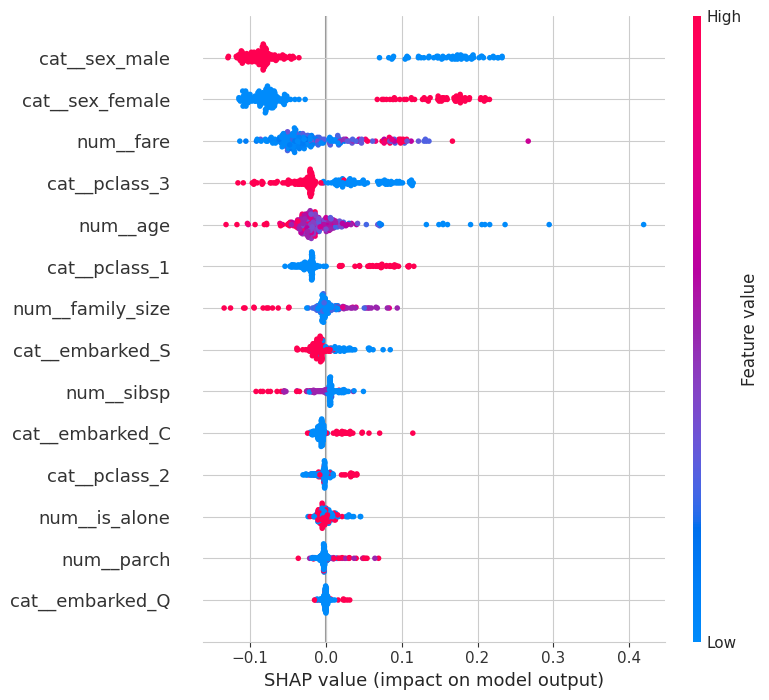

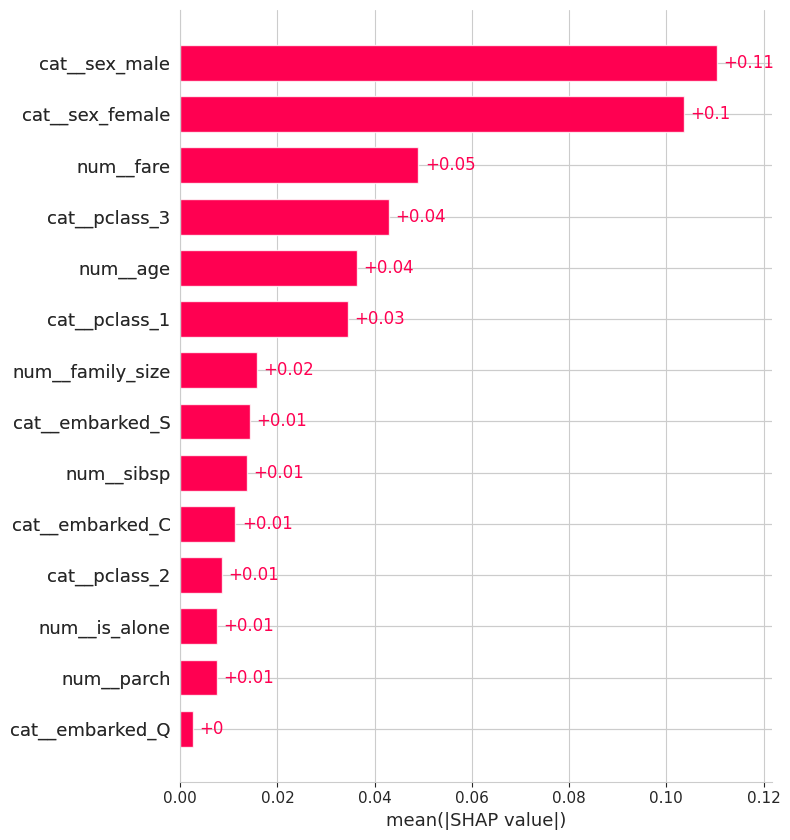

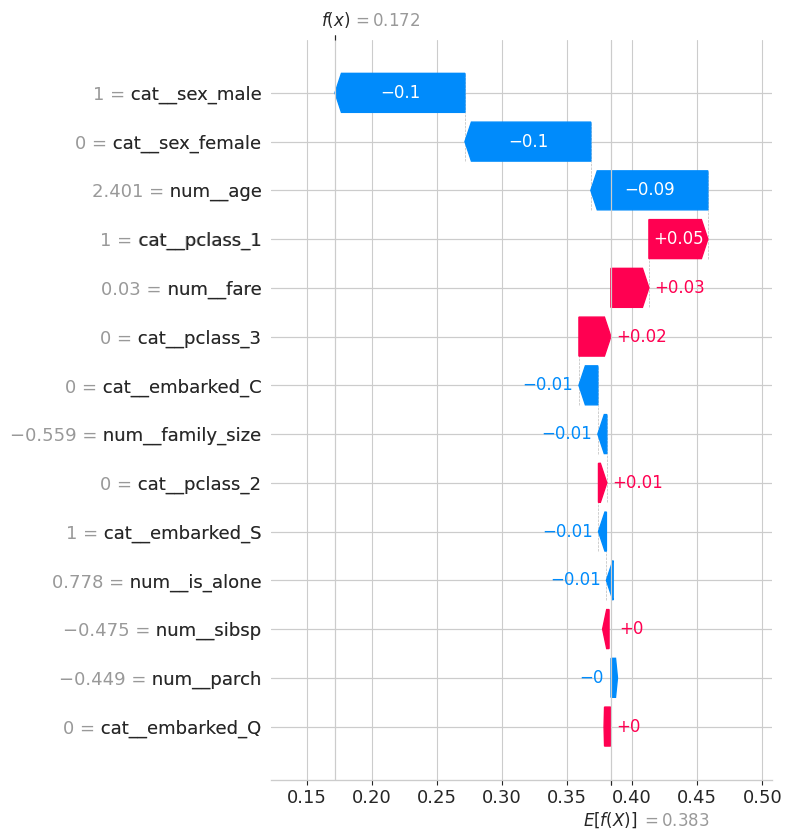


SHAP is done.

Saved SHAP files in artifacts/figures:
['shap_beeswarm.png', 'shap_waterfall_example.png', 'shap_bar.png']

Saved SHAP helper files in artifacts/models:
['shap_background.npy', 'shap_info.json']


In [54]:
# =========================
# PART 3: SHAP EXPLAINABILITY
# Run this AFTER Part 2 is done
# =========================

!pip -q install shap

import os
import json
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# -------------------------
# 1. Make sure folders exist
# -------------------------
os.makedirs("artifacts/figures", exist_ok=True)
os.makedirs("artifacts/models", exist_ok=True)

# -------------------------
# 2. Load the saved files from Part 2
# -------------------------
results_df = pd.read_csv("artifacts/models/model_results.csv")
preprocessor = joblib.load("artifacts/models/preprocessor.joblib")

print("Loaded model results and preprocessor.")

# -------------------------
# 3. Pick the best tree-based model
# Only tree-based models should be used for SHAP here
# -------------------------
tree_models = ["Decision Tree", "Random Forest", "XGBoost"]
tree_results = results_df[results_df["model"].isin(tree_models)].copy()

best_tree_name = tree_results.sort_values(by="f1", ascending=False).iloc[0]["model"]

if best_tree_name == "Decision Tree":
    best_tree_model = joblib.load("artifacts/models/decision_tree.joblib")
elif best_tree_name == "Random Forest":
    best_tree_model = joblib.load("artifacts/models/random_forest.joblib")
else:
    best_tree_model = joblib.load("artifacts/models/xgboost.joblib")

print("Best tree-based model for SHAP:", best_tree_name)

# -------------------------
# 4. Load the cleaned Titanic dataset
# This keeps everything consistent with your earlier steps
# -------------------------
df_shap = pd.read_csv("artifacts/data/titanic_clean.csv")

print("Loaded cleaned dataset.")
print("Shape:", df_shap.shape)

# -------------------------
# 5. Recreate X and y
# -------------------------
X = df_shap.drop(columns=["survived"])
y = df_shap["survived"]

# -------------------------
# 6. Recreate the same train/test split from Part 2
# Use the same random_state and stratify so it matches
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -------------------------
# 7. Transform the data using the saved preprocessor
# -------------------------
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert to dense arrays if needed
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

feature_names = preprocessor.get_feature_names_out().tolist()

print("Processed train shape:", X_train_dense.shape)
print("Processed test shape:", X_test_dense.shape)

# -------------------------
# 8. Create a small background sample for SHAP
# This makes SHAP faster
# -------------------------
background_size = min(200, X_train_dense.shape[0])
rng = np.random.RandomState(42)
background_idx = rng.choice(X_train_dense.shape[0], size=background_size, replace=False)
background_data = X_train_dense[background_idx]

# Save background data for Streamlit later
np.save("artifacts/models/shap_background.npy", background_data)

# -------------------------
# 9. Build the SHAP explainer
# -------------------------
explainer = shap.TreeExplainer(best_tree_model)

# Use the background sample for global plots
raw_shap_values = explainer(background_data)

# -------------------------
# 10. Fix SHAP output shape if model is multi-output
# For binary classification, we want the class-1 explanation
# -------------------------
if len(raw_shap_values.values.shape) == 3:
    shap_values = shap.Explanation(
        values=raw_shap_values.values[:, :, 1],
        base_values=raw_shap_values.base_values[:, 1] if len(np.array(raw_shap_values.base_values).shape) > 1 else raw_shap_values.base_values,
        data=raw_shap_values.data,
        feature_names=feature_names
    )
else:
    shap_values = shap.Explanation(
        values=raw_shap_values.values,
        base_values=raw_shap_values.base_values,
        data=raw_shap_values.data,
        feature_names=feature_names
    )

# -------------------------
# 11. SHAP beeswarm plot
# -------------------------
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig("artifacts/figures/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------
# 12. SHAP bar plot
# -------------------------
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig("artifacts/figures/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------
# 13. SHAP waterfall plot for one test example
# -------------------------
one_input = X_test_dense[0:1]
raw_one_shap = explainer(one_input)

if len(raw_one_shap.values.shape) == 3:
    one_shap = shap.Explanation(
        values=raw_one_shap.values[0, :, 1],
        base_values=raw_one_shap.base_values[0, 1] if len(np.array(raw_one_shap.base_values).shape) > 1 else raw_one_shap.base_values[0],
        data=raw_one_shap.data[0],
        feature_names=feature_names
    )
else:
    one_shap = shap.Explanation(
        values=raw_one_shap.values[0],
        base_values=raw_one_shap.base_values[0] if len(np.array(raw_one_shap.base_values).shape) > 0 else raw_one_shap.base_values,
        data=raw_one_shap.data[0],
        feature_names=feature_names
    )

plt.figure()
shap.plots.waterfall(one_shap, max_display=15, show=False)
plt.tight_layout()
plt.savefig("artifacts/figures/shap_waterfall_example.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------
# 14. Save a small info file for the Streamlit app
# -------------------------
shap_info = {
    "best_tree_model_for_shap": best_tree_name,
    "waterfall_example_index": 0
}

with open("artifacts/models/shap_info.json", "w") as f:
    json.dump(shap_info, f, indent=4)

# -------------------------
# 15. Print confirmation
# -------------------------
print("\nSHAP is done.")
print("\nSaved SHAP files in artifacts/figures:")
print([f for f in os.listdir("artifacts/figures") if "shap" in f])

print("\nSaved SHAP helper files in artifacts/models:")
print([f for f in os.listdir("artifacts/models") if "shap" in f])

In [43]:
# Part 5: Baseline Model - Logistic Regression
# In this section, I train a Logistic Regression model as the baseline and evaluate its performance.

In [55]:
# =========================
# PART 5: PACKAGE PROJECT FOR DOWNLOAD
# This zips the main project files so you can upload them to GitHub
# =========================

!zip -r titanic_project_submission.zip app.py requirements.txt README.md runtime.txt artifacts

print("Zip file created: titanic_project_submission.zip")

from google.colab import files
files.download("titanic_project_submission.zip")

	zip warning: name not matched: app.py
	zip warning: name not matched: requirements.txt
	zip warning: name not matched: README.md
	zip warning: name not matched: runtime.txt
  adding: artifacts/ (stored 0%)
  adding: artifacts/data/ (stored 0%)
  adding: artifacts/data/titanic.csv (deflated 88%)
  adding: artifacts/data/titanic_clean.csv (deflated 81%)
  adding: artifacts/models/ (stored 0%)
  adding: artifacts/models/mlp_model.keras (deflated 14%)
  adding: artifacts/models/model_results.csv (deflated 47%)
  adding: artifacts/models/preprocessor.joblib (deflated 60%)
  adding: artifacts/models/shap_background.npy (deflated 87%)
  adding: artifacts/models/shap_info.json (deflated 7%)
  adding: artifacts/models/decision_tree.joblib (deflated 62%)
  adding: artifacts/models/logistic_regression.joblib (deflated 30%)
  adding: artifacts/models/best_params.json (deflated 52%)
  adding: artifacts/models/random_forest.joblib (deflated 81%)
  adding: artifacts/models/xgboost.joblib (deflated 7

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
# =========================
# FINAL REPAIR + VERIFY + PACKAGE CELL (FIXED)
# =========================

import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import dedent

# -------------------------
# 1. Make sure folders exist
# -------------------------
os.makedirs("artifacts/data", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)
os.makedirs("artifacts/models", exist_ok=True)

# -------------------------
# 2. Load cleaned dataset
# -------------------------
if os.path.exists("artifacts/data/titanic_clean.csv"):
    df_app = pd.read_csv("artifacts/data/titanic_clean.csv")
    print("Loaded cleaned dataset from artifacts/data/titanic_clean.csv")
else:
    df_app = sns.load_dataset("titanic")
    df_app = df_app[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
    df_app["family_size"] = df_app["sibsp"] + df_app["parch"] + 1
    df_app["is_alone"] = (df_app["family_size"] == 1).astype(int)
    df_app["age"] = df_app["age"].fillna(df_app["age"].median())
    df_app["embarked"] = df_app["embarked"].fillna(df_app["embarked"].mode()[0])
    df_app.to_csv("artifacts/data/titanic_clean.csv", index=False)
    print("Rebuilt and saved cleaned dataset.")

print("Dataset shape:", df_app.shape)

# -------------------------
# 3. Recreate and save all Part 1 figures
# -------------------------

plt.figure(figsize=(6,4))
sns.countplot(data=df_app, x="survived")
plt.title("Target Distribution: Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("artifacts/figures/target_distribution.png", dpi=300)
plt.close()

plt.figure(figsize=(6,4))
sns.barplot(data=df_app, x="sex", y="survived", errorbar=None)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.tight_layout()
plt.savefig("artifacts/figures/survival_by_sex.png", dpi=300)
plt.close()

plt.figure(figsize=(6,4))
sns.barplot(data=df_app, x="pclass", y="survived", errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival Rate")
plt.tight_layout()
plt.savefig("artifacts/figures/survival_by_pclass.png", dpi=300)
plt.close()

plt.figure(figsize=(7,4))
sns.boxplot(data=df_app, x="survived", y="age")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig("artifacts/figures/age_by_survival.png", dpi=300)
plt.close()

plt.figure(figsize=(7,4))
sns.boxplot(data=df_app, x="survived", y="fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("artifacts/figures/fare_by_survival.png", dpi=300)
plt.close()

plt.figure(figsize=(7,4))
sns.barplot(data=df_app, x="family_size", y="survived", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")
plt.tight_layout()
plt.savefig("artifacts/figures/family_size_by_survival.png", dpi=300)
plt.close()

corr_df = df_app.copy()
corr_df["sex"] = corr_df["sex"].map({"male": 0, "female": 1})
corr_df["embarked"] = corr_df["embarked"].map({"S": 0, "C": 1, "Q": 2})

plt.figure(figsize=(10,6))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("artifacts/figures/correlation_heatmap.png", dpi=300)
plt.close()

print("Saved all required Part 1 figures.")

# -------------------------
# 4. Check required model files
# -------------------------
required_model_files = [
    "artifacts/models/model_results.csv",
    "artifacts/models/preprocessor.joblib",
    "artifacts/models/logistic_regression.joblib",
    "artifacts/models/decision_tree.joblib",
    "artifacts/models/random_forest.joblib",
    "artifacts/models/xgboost.joblib",
    "artifacts/models/mlp_model.keras",
    "artifacts/models/best_params.json",
    "artifacts/models/shap_background.npy",
    "artifacts/models/shap_info.json",
]

missing_model_files = [f for f in required_model_files if not os.path.exists(f)]

if missing_model_files:
    print("\nWARNING: These model files are missing:")
    for f in missing_model_files:
        print("-", f)
else:
    print("\nAll required model files are present.")

# -------------------------
# 5. Create app.py
# -------------------------
app_code = dedent("""
import os
import json
import numpy as np
import pandas as pd
import joblib
import streamlit as st
import matplotlib.pyplot as plt
import shap
import tensorflow as tf

ART = "artifacts"
FIG_DIR = os.path.join(ART, "figures")
MODEL_DIR = os.path.join(ART, "models")

st.set_page_config(page_title="Titanic Survival Prediction", layout="wide")

@st.cache_resource
def load_artifacts():
    preprocessor = joblib.load(os.path.join(MODEL_DIR, "preprocessor.joblib"))
    results_df = pd.read_csv(os.path.join(MODEL_DIR, "model_results.csv"))

    models = {
        "Logistic Regression": joblib.load(os.path.join(MODEL_DIR, "logistic_regression.joblib")),
        "Decision Tree": joblib.load(os.path.join(MODEL_DIR, "decision_tree.joblib")),
        "Random Forest": joblib.load(os.path.join(MODEL_DIR, "random_forest.joblib")),
        "XGBoost": joblib.load(os.path.join(MODEL_DIR, "xgboost.joblib")),
        "MLP Neural Network": tf.keras.models.load_model(os.path.join(MODEL_DIR, "mlp_model.keras"))
    }

    with open(os.path.join(MODEL_DIR, "best_params.json"), "r") as f:
        best_params = json.load(f)

    with open(os.path.join(MODEL_DIR, "shap_info.json"), "r") as f:
        shap_info = json.load(f)

    shap_background = np.load(os.path.join(MODEL_DIR, "shap_background.npy"))

    return preprocessor, results_df, models, best_params, shap_info, shap_background

preprocessor, results_df, models, best_params, shap_info, shap_background = load_artifacts()

st.title("Titanic Survival Prediction: End-to-End Data Science Workflow")

tab1, tab2, tab3, tab4 = st.tabs([
    "Executive Summary",
    "Descriptive Analytics",
    "Model Performance",
    "Explainability & Interactive Prediction"
])

with tab1:
    st.header("Executive Summary")

    st.write(
        "This project uses the Titanic dataset to predict whether a passenger survived or did not survive. "
        "The target variable is survived, where 1 means the passenger survived and 0 means the passenger did not survive. "
        "The features used in this analysis include passenger class, sex, age, fare, family information, and port of embarkation."
    )

    st.write(
        "This problem matters because it is a simple but useful example of how machine learning can uncover patterns in real-world outcomes. "
        "In this case, the models help show how demographic and travel-related features relate to survival. "
        "The same workflow can be applied to more serious problems such as customer churn, fraud detection, and health risk prediction."
    )

    st.write(
        "I first explored the data visually to understand how survival changed across key features such as sex, passenger class, age, fare, and family size. "
        "I then trained and compared five classification models: Logistic Regression, Decision Tree, Random Forest, XGBoost, and a Neural Network."
    )

    best_model_name = results_df.sort_values(by="f1", ascending=False).iloc[0]["model"]
    best_model_f1 = results_df.sort_values(by="f1", ascending=False).iloc[0]["f1"]
    best_model_auc = results_df.sort_values(by="roc_auc", ascending=False).iloc[0]["roc_auc"]

    st.write(
        f"After comparing all models using accuracy, precision, recall, F1 score, and ROC-AUC, the strongest model was {best_model_name}. "
        f"It achieved an F1 score of {best_model_f1:.3f} and a ROC-AUC of {best_model_auc:.3f} on the test set. "
        "I then used SHAP to explain the best tree-based model and built this app so a user can interact with the results directly."
    )

with tab2:
    st.header("Descriptive Analytics")

    plots_and_captions = [
        ("target_distribution.png",
         "This plot shows the number of passengers who survived and did not survive. "
         "It shows that the classes are not perfectly balanced, so later model evaluation should not rely only on accuracy."),
        ("survival_by_sex.png",
         "This plot shows that female passengers had a much higher survival rate than male passengers. "
         "This suggests that sex is one of the strongest predictors of survival in the dataset."),
        ("survival_by_pclass.png",
         "This plot shows that first-class passengers had the highest survival rate and third-class passengers had the lowest. "
         "This suggests that passenger class strongly influenced survival outcomes."),
        ("age_by_survival.png",
         "This plot compares the age distribution of survivors and non-survivors. "
         "The two groups overlap, but age still adds useful predictive information."),
        ("fare_by_survival.png",
         "This plot shows that passengers who survived often had higher ticket fares. "
         "Because fare is related to class and status, it likely captures an important survival pattern."),
        ("correlation_heatmap.png",
         "This heatmap summarizes the relationships among the numeric and encoded features. "
         "It supports the earlier findings that class, sex, and fare are strongly related to survival.")
    ]

    for plot_file, caption in plots_and_captions:
        st.image(os.path.join(FIG_DIR, plot_file), use_container_width=True)
        st.caption(caption)

with tab3:
    st.header("Model Performance")

    st.subheader("Model Comparison Table")
    st.dataframe(results_df, use_container_width=True)

    st.subheader("Model Comparison by F1 Score")
    st.image(os.path.join(FIG_DIR, "model_comparison_f1.png"), use_container_width=True)

    st.subheader("ROC Curves")
    roc_files = [
        "roc_logistic_regression.png",
        "roc_decision_tree.png",
        "roc_random_forest.png",
        "roc_xgboost.png",
        "roc_mlp.png"
    ]

    for roc_file in roc_files:
        path = os.path.join(FIG_DIR, roc_file)
        if os.path.exists(path):
            st.image(path, use_container_width=True)

    st.subheader("Best Hyperparameters")
    st.json(best_params)

    st.subheader("Neural Network Training History")
    st.image(os.path.join(FIG_DIR, "mlp_loss_curve.png"), use_container_width=True)
    st.image(os.path.join(FIG_DIR, "mlp_accuracy_curve.png"), use_container_width=True)

with tab4:
    st.header("Explainability & Interactive Prediction")

    st.subheader("SHAP Global Explainability")
    st.image(os.path.join(FIG_DIR, "shap_beeswarm.png"), use_container_width=True)
    st.caption("The SHAP beeswarm plot shows which features had the largest overall effect on predictions and whether they pushed the prediction up or down.")

    st.image(os.path.join(FIG_DIR, "shap_bar.png"), use_container_width=True)
    st.caption("The SHAP bar plot ranks features by average importance, which helps identify the strongest drivers of model behavior.")

    st.subheader("Interactive Prediction")

    selected_model = st.selectbox(
        "Choose a model for prediction",
        list(models.keys()),
        index=3
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        sex = st.selectbox("Sex", ["male", "female"])
        embarked = st.selectbox("Embarked", ["S", "C", "Q"])
        pclass = st.selectbox("Passenger Class", [1, 2, 3])

    with col2:
        age = st.slider("Age", 0, 80, 30)
        sibsp = st.slider("Siblings/Spouses Aboard", 0, 8, 0)
        parch = st.slider("Parents/Children Aboard", 0, 6, 0)

    with col3:
        fare = st.slider("Fare", 0.0, 600.0, 32.0, 1.0)

    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0

    input_df = pd.DataFrame([{
        "pclass": pclass,
        "sex": sex,
        "age": age,
        "sibsp": sibsp,
        "parch": parch,
        "fare": fare,
        "embarked": embarked,
        "family_size": family_size,
        "is_alone": is_alone
    }])

    X_input_processed = preprocessor.transform(input_df)
    X_input_dense = X_input_processed.toarray() if hasattr(X_input_processed, "toarray") else X_input_processed

    if selected_model == "MLP Neural Network":
        pred_prob = float(models[selected_model].predict(X_input_dense, verbose=0).ravel()[0])
    else:
        pred_prob = float(models[selected_model].predict_proba(X_input_processed)[:, 1][0])

    pred_class = 1 if pred_prob >= 0.5 else 0

    st.metric("Predicted Class", pred_class)
    st.metric("Predicted Survival Probability", f"{pred_prob:.2%}")

    st.subheader("SHAP Waterfall for Custom Input")

    shap_model_name = shap_info["best_tree_model_for_shap"]
    shap_model = models[shap_model_name]
    explainer = shap.TreeExplainer(shap_model)

    raw_shap_values = explainer(X_input_dense)

    if len(raw_shap_values.values.shape) == 3:
        one_shap = shap.Explanation(
            values=raw_shap_values.values[0, :, 1],
            base_values=raw_shap_values.base_values[0, 1] if len(np.array(raw_shap_values.base_values).shape) > 1 else raw_shap_values.base_values[0],
            data=raw_shap_values.data[0],
            feature_names=preprocessor.get_feature_names_out().tolist()
        )
    else:
        one_shap = shap.Explanation(
            values=raw_shap_values.values[0],
            base_values=raw_shap_values.base_values[0] if len(np.array(raw_shap_values.base_values).shape) > 0 else raw_shap_values.base_values,
            data=raw_shap_values.data[0],
            feature_names=preprocessor.get_feature_names_out().tolist()
        )

    fig = plt.figure()
    shap.plots.waterfall(one_shap, max_display=15, show=False)
    st.pyplot(fig, clear_figure=True)

    st.caption(f"This SHAP waterfall plot uses the best tree-based model: {shap_model_name}.")
""")

with open("app.py", "w") as f:
    f.write(app_code)

# -------------------------
# 6. Create requirements.txt
# -------------------------
requirements_text = dedent("""
streamlit
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
shap
xgboost
tensorflow
""").strip() + "\n"

with open("requirements.txt", "w") as f:
    f.write(requirements_text)

# -------------------------
# 7. Create README.md
# -------------------------
readme_text = dedent("""
# Titanic Survival Prediction App

This project demonstrates a full end-to-end data science workflow using the Titanic dataset.

## Included
- Exploratory Data Analysis
- Predictive modeling with 5 models
- Model comparison
- SHAP explainability
- Streamlit deployment

## Files
- `app.py`: Streamlit application
- `artifacts/models/`: saved models and preprocessing artifacts
- `artifacts/figures/`: saved plots
- `requirements.txt`: required Python packages

## Run locally
pip install -r requirements.txt
streamlit run app.py

## Deployment
This app is designed to be deployed on Streamlit Community Cloud.
""").strip() + "\n"

with open("README.md", "w") as f:
    f.write(readme_text)

# -------------------------
# 8. Create runtime.txt
# -------------------------
with open("runtime.txt", "w") as f:
    f.write("python-3.10\n")

# -------------------------
# 9. Verify files
# -------------------------
required_figure_files = [
    "artifacts/figures/target_distribution.png",
    "artifacts/figures/survival_by_sex.png",
    "artifacts/figures/survival_by_pclass.png",
    "artifacts/figures/age_by_survival.png",
    "artifacts/figures/fare_by_survival.png",
    "artifacts/figures/correlation_heatmap.png",
    "artifacts/figures/roc_logistic_regression.png",
    "artifacts/figures/roc_decision_tree.png",
    "artifacts/figures/roc_random_forest.png",
    "artifacts/figures/roc_xgboost.png",
    "artifacts/figures/roc_mlp.png",
    "artifacts/figures/model_comparison_f1.png",
    "artifacts/figures/mlp_loss_curve.png",
    "artifacts/figures/mlp_accuracy_curve.png",
    "artifacts/figures/shap_beeswarm.png",
    "artifacts/figures/shap_bar.png",
    "artifacts/figures/shap_waterfall_example.png",
]

required_root_files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "runtime.txt",
    "artifacts/data/titanic_clean.csv"
]

missing_figures = [f for f in required_figure_files if not os.path.exists(f)]
missing_root = [f for f in required_root_files if not os.path.exists(f)]

print("\n=== VERIFICATION ===")
print("Missing root files:", missing_root if missing_root else "None")
print("Missing figure files:", missing_figures if missing_figures else "None")
print("Missing model files:", missing_model_files if missing_model_files else "None")

# -------------------------
# 10. Create zip
# -------------------------
zip_name = "titanic_project_submission.zip"
if os.path.exists(zip_name):
    os.remove(zip_name)

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for f in ["app.py", "requirements.txt", "README.md", "runtime.txt"]:
        if os.path.exists(f):
            zipf.write(f)

    for root, dirs, files in os.walk("artifacts"):
        for file in files:
            full_path = os.path.join(root, file)
            zipf.write(full_path)

print(f"\nCreated zip file: {zip_name}")

print("\n=== ROOT FILES ===")
for f in ["app.py", "requirements.txt", "README.md", "runtime.txt", zip_name]:
    print(f, "->", os.path.exists(f))

print("\n=== artifacts/data ===")
print(os.listdir("artifacts/data"))

print("\n=== artifacts/models ===")
print(os.listdir("artifacts/models"))

print("\n=== artifacts/figures ===")
print(os.listdir("artifacts/figures"))

try:
    from google.colab import files
    files.download(zip_name)
except Exception:
    print("\nDownload helper skipped. You can manually download:", zip_name)

Loaded cleaned dataset from artifacts/data/titanic_clean.csv
Dataset shape: (891, 10)
Saved all required Part 1 figures.

All required model files are present.

=== VERIFICATION ===
Missing root files: None
Missing figure files: None
Missing model files: None

Created zip file: titanic_project_submission.zip

=== ROOT FILES ===
app.py -> True
requirements.txt -> True
README.md -> True
runtime.txt -> True
titanic_project_submission.zip -> True

=== artifacts/data ===
['titanic.csv', 'titanic_clean.csv']

=== artifacts/models ===
['mlp_model.keras', 'model_results.csv', 'preprocessor.joblib', 'shap_background.npy', 'shap_info.json', 'decision_tree.joblib', 'logistic_regression.joblib', 'best_params.json', 'random_forest.joblib', 'xgboost.joblib', 'feature_names.json']

=== artifacts/figures ===
['mlp_accuracy_curve.png', 'survival_by_pclass.png', 'roc_random_forest.png', 'roc_logistic_regression.png', 'roc_decision_tree.png', 'shap_beeswarm.png', 'shap_waterfall_example.png', 'roc_mlp.pn

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>